In [2]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder

import cv2
import numpy as np



In [3]:
##FUNCIONES DE SU APOYO

def superponer_imagenes_con_fondo_blanco(images, white_threshold=245):
    """
    images: arreglo de imágenes a empilar
    Se retorna una imagen final RGB compuesta
    """
    h, w = np.array(images[0]).shape[:2]
    # Se crea una imagen con fndo blanco
    canvas_rgba = np.ones((h, w, 4), dtype=np.uint8) * 255

    for img_bgr in images:
        # Se inicaliza el valor alfa al máximo valor (255)
        img_bgr = np.array(img_bgr)
        bgra = np.dstack([img_bgr, np.ones((h, w), dtype=np.uint8) * 255])
        # Se genera una máscara de pixeles
        mask = (img_bgr[:, :, 0] >= white_threshold) & \
               (img_bgr[:, :, 1] >= white_threshold) & \
               (img_bgr[:, :, 2] >= white_threshold)
        bgra[mask, 3] = 0  # Se transparentizan los pixeles alfas

        # Se realiza el mezclado
        alpha = bgra[:, :, 3:] / 255.0
        fore = bgra[:, :, :3].astype(np.float32)
        back = canvas_rgba[:, :, :3].astype(np.float32)
        composite = (fore * alpha + back * (1 - alpha)).astype(np.uint8)

        canvas_rgba[:, :, :3] = composite
        canvas_rgba[:, :, 3] = 255  # Mantener el valor opaco

    return canvas_rgba[:, :, :3]  # Eliminación del alfa

def colorear(img, new_color):
    """
    img: imagen de base
    new_color: codificación RGB de un color para cambiar la imagen
    Se retorna una imagen con todos los pixeles que no sean blancos del color indicado
    """

    img = np.array(img)
    # Definición del umbral de blanco
    lower = np.array([200, 200, 200])  # near white
    upper = np.array([255, 255, 255])  # pure white
    # Se crea una máscara para blanco
    mask = cv2.inRange(img, lower, upper)
    # Se invierte la máscara
    mask_inv = cv2.bitwise_not(mask)
    # Se crea una imagen de color sólido
    colored = np.full_like(img, new_color)
    # Se aplica el color indicado a las regiones no-blancas
    result = cv2.bitwise_and(colored, colored, mask=mask_inv)
    # Se retorna la imagen combinada con el fondo original
    final = cv2.bitwise_or(result, cv2.bitwise_and(img, img, mask=mask))

    return final

def crear_wrodler(base, hairs, hair_colors, clothes, cloth_colors, accesories, hair, hair_color, cloth, cloth_color, accesory):
    """
    base: imagen base del wrodler
    hairs, hair_colors, clothes, cloth_colors: arreglos que contienen las imagenes de base de estilos
    hair, cloth, accesory: arreglos que contienen los elementos a usar
    hair_color, cloth_color: arreglos que contienen los colores a usar para los elementos
    Se retorna un wrodler a partir de sus especificaciones
    """
    hair = colorear(hairs[hair], hair_colors[hair_color])
    cloth = colorear(clothes[cloth], cloth_colors[cloth_color])
    accesory = accesories[accesory]

    res =  superponer_imagenes_con_fondo_blanco([base, accesory, cloth, hair])
    return (Image.fromarray(res))

In [4]:
# Cargar los datos del csv
df = pd.read_csv('Imagenes y Datos/estilos.csv')
df.head()


,accesorio,pelo,color_pelo,ropa,color_ropa
0,gafas,calvo,negro,hoodie,negro
1,ninguno,liso-corto,rosa,camiseta,azul
2,gafas oscuras,rizado,rojo,overol,verde
3,ninguno,liso-hombros,plateado,overol,gris
4,gafas,rizado,rosa,camiseta,naranja


In [13]:
from PIL import Image
import numpy as np
from os import listdir
import glob
from os.path import isfile, join

images=[]


for filename in glob.glob('Imagenes y Datos/*.png'):
    images.append(Image.open(filename).convert('RGB'))
#Base del wrodler
base = images[2]
#Diccionario de accesorios
accesories = {'ninguno':Image.new('RGB', (240, 284), color='white'), 'gafas':images[0], 'gafas oscuras': images[1]}
#Diccionario de pelos
hairs = {'calvo':Image.new('RGB', (240, 284), color='white') , 'liso-corto':images[3], 'rizado':images[4], 'liso-hombros': images[5]}
#Diccionario de colores de pelo
hair_colors = { 'café':[168, 112, 78], 'negro':[0,0,0], 'rosa':[254,127,156], 'plateado':[165,169,180],  'rojo':[139,0,0]}
#Diccionario de ropas
clothes = {'hoodie':images[6], 'camiseta':images[7], 'overol': images[8]}
#Diccionario de colores de ropa
cloth_colors = {'negro':[0,0,0], 'azul': [0,0,140], 'gris':[58,58,58], 'verde':[0,128,0], 'naranja':[255,128,0], 'rojo':[194,24,7], 'blanco':[142,142,142]}


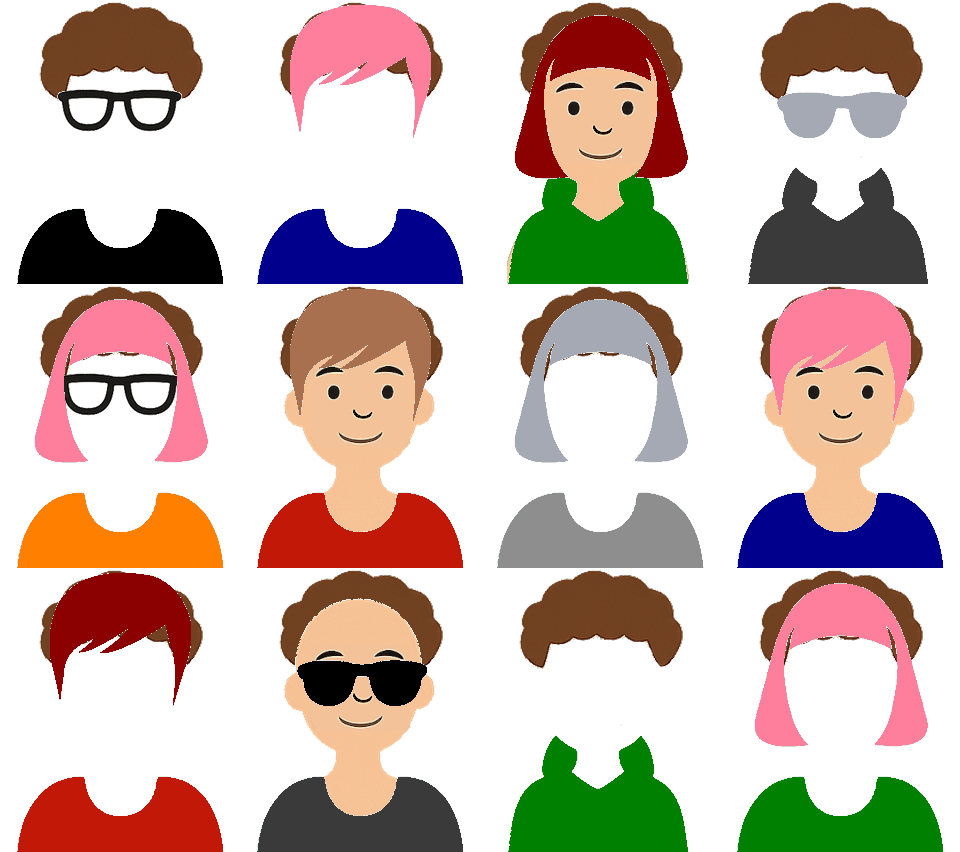

In [14]:
wrodlers = []
for index, row in df.iterrows():
    wrodlers.append(crear_wrodler(base, hairs, hair_colors, clothes, cloth_colors, accesories, row['pelo'],row['color_pelo'],row['ropa'],row['color_ropa'],row['accesorio']))


wrodlers_rows = []
for i in range(0,len(wrodlers)//4):
    wrodlers_rows.append(np.hstack(wrodlers[i*4:(i+1)*4]))
wrodlers_matrix = np.vstack(wrodlers_rows)


wrodlers_final = Image.fromarray(wrodlers_matrix)
display(wrodlers_final)


Nuevo Wrodler generada por Naive Bayes sobre el dataset de atributos:


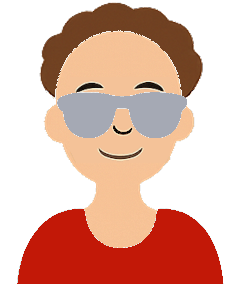

In [15]:
# No hay columna objetivo, así que generaremos un nuevo vector de características
# Codificamos todas las columnas
le_dict = {}
df_enc = pd.DataFrame()
for col in df.columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# Usamos CategoricalNB ya que sólo tenemos variables categóricas
X = df_enc.values
model = CategoricalNB()
# Generamos etiquetas de mentiras, sólo para ajustar la "distribución empírica" de Naive Bayes
model.fit(X, np.zeros(X.shape[0]))  

# Generar nueva observación: para cada variable, sampleamos una categoría según sus frecuencias
new_obs_encoded = []
for i, col in enumerate(df.columns):
    feature_probs = np.bincount(X[:, i]) / X.shape[0]
    sampled_cat = np.random.choice(np.arange(len(feature_probs)), p=feature_probs)
    new_obs_encoded.append(sampled_cat)

# Asignamos a cada etiqueta su valor categórico
new_obs = {}
for idx, col in enumerate(df.columns):
    new_obs[col] = le_dict[col].inverse_transform([new_obs_encoded[idx]])[0]

print("Nuevo Wrodler generada por Naive Bayes sobre el dataset de atributos:")
wrodler_gen = crear_wrodler(base, hairs, hair_colors, clothes, cloth_colors, accesories,  new_obs['pelo'],new_obs['color_pelo'],new_obs['ropa'],new_obs['color_ropa'],new_obs['accesorio'])
display(wrodler_gen)

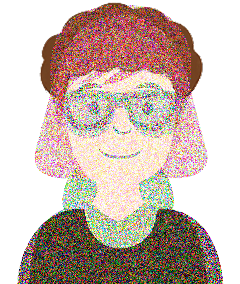

In [16]:
#Generación de valores individuales de pixeles con Naive Bayes

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB

#Convertimos nuestras imágenes en arreglos de pixeles

X = [np.asarray(wrod).flatten() for wrod in wrodlers]
X = pd.DataFrame(data=(X))

clf = GaussianNB()
clf.fit(X, np.zeros(X.shape[0]))

probs = clf.class_prior_ # Probabilidades de clase aprendidas
sampled_class = np.random.choice(clf.classes_, p=probs)

#  Generamos una observación usando la distribución de probabilidad para cada pixel
features = X.columns
X_new = {}
for i, col in enumerate(X.columns):
    mean = clf.theta_[0, i]
    var = clf.var_[0, i]
    # Sample from N(mean, std) as NB would
    sample = round(np.random.normal(mean, np.sqrt(var)))

    #Tenemos que truncar valores fuera del rango [0,255]
    if sample < 0:
        X_new[col] = 0
    elif sample > 255:
        X_new[col] = 255
    else:
        X_new[col] = sample


result = X_new.copy()

#Mostramos el resultado
img = np.asarray(list(result.values())).reshape(284,240,3)
Image.fromarray(img.astype(np.uint8))

In [17]:
img

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]